In [1]:
!pip install -q pandas scikit-learn

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
import time
import os

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
OUTPUT_DIR = '/content/drive/MyDrive/word_problem_results/F2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Results will be saved to: {OUTPUT_DIR}")

Results will be saved to: /content/drive/MyDrive/word_problem_results/F2


In [4]:
DATA_DIR = '/content/F2'

In [7]:
df_synthetic = pd.read_csv(os.path.join(DATA_DIR, 'f2_synthetic_100k.csv'))
df_augmented = pd.read_csv(os.path.join(DATA_DIR, 'f2_augmented_100k.csv'))
df_hard = pd.read_csv(os.path.join(DATA_DIR, 'f2_hard_100k.csv'))

In [10]:
print(f"Synthetic: {len(df_synthetic)} rows")
print(f"Augmented: {len(df_augmented)} rows")
print(f"Hard: {len(df_hard)} rows")
print(df_synthetic.head())

Synthetic: 100000 rows
Augmented: 100000 rows
Hard: 100000 rows
                                  word  label  length        source
0                       BBaBbaBAAbaAbB      0      14  f2_synthetic
1       ABAaAaabAabAABaAAAABBBAbBBBbAb      0      30  f2_synthetic
2                 BAbbabAAaaAAaaBABBab      1      20  f2_synthetic
3  abbbbbaabbbaABBbbbaababBbBabbBABAab      0      35  f2_synthetic
4                         AABAAbBaabaa      1      12  f2_synthetic


In [11]:
# %% CELL 5: Tokenizer
# F2 alphabet: a, A (inverse), b, B (inverse)
VOCAB = {'<PAD>': 0, 'a': 1, 'A': 2, 'b': 3, 'B': 4}
VOCAB_SIZE = len(VOCAB)

def encode(word):
    """Convert string to list of token ids"""
    return [VOCAB.get(c, 0) for c in word]

# Test
print(f"Vocab: {VOCAB}")
print(f"encode('abAB') = {encode('abAB')}")

# %% CELL 6: Dataset Class
class WordProblemDataset(Dataset):
    def __init__(self, words, labels):
        self.words = words
        self.labels = labels

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        encoded = encode(self.words[idx])
        return encoded, self.labels[idx], len(encoded)

def collate_fn(batch):
    """Pad sequences to same length within batch"""
    words, labels, lengths = zip(*batch)
    max_len = max(lengths)

    padded = []
    for w in words:
        padded.append(w + [0] * (max_len - len(w)))

    # Sort by length (descending) for pack_padded_sequence
    sorted_indices = sorted(range(len(lengths)), key=lambda i: lengths[i], reverse=True)

    padded_sorted = [padded[i] for i in sorted_indices]
    labels_sorted = [labels[i] for i in sorted_indices]
    lengths_sorted = [lengths[i] for i in sorted_indices]

    return (
        torch.tensor(padded_sorted),
        torch.tensor(labels_sorted, dtype=torch.float),
        torch.tensor(lengths_sorted)
    )

# %% CELL 7: LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]

        return self.classifier(hidden).squeeze(-1)

# %% CELL 8: Transformer Model
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4,
                 num_layers=2, dropout=0.3, max_len=200):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, input_ids, lengths):
        batch_size, seq_len = input_ids.shape

        # Embeddings + positional
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)
        embedded = self.embedding(input_ids) + self.pos_encoding(positions)

        # Padding mask (True = ignore)
        mask = (input_ids == 0)

        # Transformer
        output = self.transformer(embedded, src_key_padding_mask=mask)

        # Mean pooling (ignore padding)
        mask_expanded = (~mask).unsqueeze(-1).float()
        pooled = (output * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)

        return self.classifier(pooled).squeeze(-1)

print("Models defined: LSTMClassifier, TransformerClassifier")

# %% CELL 9: Training Function
def train_model(model, train_loader, val_loader, epochs=30, patience=5, lr=0.001):
    """Train model with early stopping"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for input_ids, labels, lengths in train_loader:
            input_ids, labels, lengths = input_ids.to(device), labels.to(device), lengths.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for input_ids, labels, lengths in val_loader:
                input_ids, labels, lengths = input_ids.to(device), labels.to(device), lengths.to(device)
                outputs = model(input_ids, lengths)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Restore best model
    if best_model_state:
        model.load_state_dict(best_model_state)

    return history, best_val_acc

# %% CELL 10: Evaluation Function
def evaluate_model(model, test_loader):
    """Evaluate model on test set"""
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_ids, labels, lengths in test_loader:
            input_ids, labels, lengths = input_ids.to(device), labels.to(device), lengths.to(device)
            outputs = model(input_ids, lengths)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, all_preds, all_labels

# %% CELL 11: Length Generalization Test
def test_length_generalization(model, df, train_max_len=50):
    """Test on sequences longer than training data"""
    # Filter to longer sequences
    long_df = df[df['length'] > train_max_len].copy()
    if len(long_df) == 0:
        return None, 0

    dataset = WordProblemDataset(long_df['word'].tolist(), long_df['label'].tolist())
    loader = DataLoader(dataset, batch_size=64, collate_fn=collate_fn)

    acc, _, _ = evaluate_model(model, loader)
    return acc, len(long_df)

# %% CELL 12: Run Single Experiment
def run_experiment(df, model_type, seed, dataset_name):
    """Run single training experiment"""
    print(f"\n{'='*60}")
    print(f"Model: {model_type} | Dataset: {dataset_name} | Seed: {seed}")
    print(f"{'='*60}")

    # Set seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # Split data
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=seed)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed)

    # Create datasets
    train_dataset = WordProblemDataset(train_df['word'].tolist(), train_df['label'].tolist())
    val_dataset = WordProblemDataset(val_df['word'].tolist(), val_df['label'].tolist())
    test_dataset = WordProblemDataset(test_df['word'].tolist(), test_df['label'].tolist())

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=64, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=collate_fn)

    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    # Create model
    if model_type == 'LSTM':
        model = LSTMClassifier(VOCAB_SIZE).to(device)
    else:  # Transformer
        model = TransformerClassifier(VOCAB_SIZE).to(device)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {params:,}")

    # Train
    start_time = time.time()
    history, best_val_acc = train_model(model, train_loader, val_loader)
    train_time = time.time() - start_time

    # Evaluate
    test_acc, _, _ = evaluate_model(model, test_loader)

    # Length generalization (if hard dataset has longer sequences)
    len_gen_acc, len_gen_count = test_length_generalization(model, df)

    print(f"\nResults:")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Training Time: {train_time:.1f}s")
    if len_gen_acc:
        print(f"  Length Gen Accuracy: {len_gen_acc:.4f} (n={len_gen_count})")

    return {
        'model': model_type,
        'dataset': dataset_name,
        'seed': seed,
        'test_acc': test_acc,
        'val_acc': best_val_acc,
        'train_time': train_time,
        'len_gen_acc': len_gen_acc,
        'len_gen_count': len_gen_count,
        'epochs': len(history['train_acc'])
    }


Vocab: {'<PAD>': 0, 'a': 1, 'A': 2, 'b': 3, 'B': 4}
encode('abAB') = [1, 3, 2, 4]
Models defined: LSTMClassifier, TransformerClassifier


In [12]:
# %% CELL 13: Run All Experiments
SEEDS = [42, 123, 456]
MODEL_TYPES = ['LSTM', 'Transformer']
DATASET_NAMES = ['synthetic', 'augmented', 'hard']

all_results = []

for dataset_name in DATASET_NAMES:
    df = datasets[dataset_name]
    for model_type in MODEL_TYPES:
        for seed in SEEDS:
            result = run_experiment(df, model_type, seed, dataset_name)
            all_results.append(result)

            # Save intermediate results
            results_df = pd.DataFrame(all_results)
            results_df.to_csv(f'{OUTPUT_DIR}/f2_results_partial.csv', index=False)

print("\n" + "="*60)
print("ALL EXPERIMENTS COMPLETE")
print("="*60)


Model: LSTM | Dataset: synthetic | Seed: 42
Train: 70000 | Val: 15000 | Test: 15000
Parameters: 627,265
Epoch 1/30 | Train Acc: 0.9528 | Val Acc: 0.9891
Epoch 2/30 | Train Acc: 0.9902 | Val Acc: 0.9916
Epoch 3/30 | Train Acc: 0.9941 | Val Acc: 0.9931
Epoch 4/30 | Train Acc: 0.9953 | Val Acc: 0.9934
Epoch 5/30 | Train Acc: 0.9960 | Val Acc: 0.9946
Epoch 6/30 | Train Acc: 0.9969 | Val Acc: 0.9969
Epoch 7/30 | Train Acc: 0.9971 | Val Acc: 0.9963
Epoch 8/30 | Train Acc: 0.9980 | Val Acc: 0.9969
Epoch 9/30 | Train Acc: 0.9980 | Val Acc: 0.9970
Epoch 10/30 | Train Acc: 0.9982 | Val Acc: 0.9967
Epoch 11/30 | Train Acc: 0.9983 | Val Acc: 0.9981
Epoch 12/30 | Train Acc: 0.9988 | Val Acc: 0.9970
Epoch 13/30 | Train Acc: 0.9989 | Val Acc: 0.9977
Epoch 14/30 | Train Acc: 0.9990 | Val Acc: 0.9971
Epoch 15/30 | Train Acc: 0.9991 | Val Acc: 0.9977
Epoch 16/30 | Train Acc: 0.9989 | Val Acc: 0.9982
Epoch 17/30 | Train Acc: 0.9991 | Val Acc: 0.9976
Epoch 18/30 | Train Acc: 0.9994 | Val Acc: 0.9980
Epoc

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/30 | Train Acc: 0.9161 | Val Acc: 0.9847
Epoch 2/30 | Train Acc: 0.9776 | Val Acc: 0.9862
Epoch 3/30 | Train Acc: 0.9803 | Val Acc: 0.9883
Epoch 4/30 | Train Acc: 0.9802 | Val Acc: 0.9895
Epoch 5/30 | Train Acc: 0.9843 | Val Acc: 0.9873
Epoch 6/30 | Train Acc: 0.9838 | Val Acc: 0.9883
Epoch 7/30 | Train Acc: 0.9843 | Val Acc: 0.9907
Epoch 8/30 | Train Acc: 0.9853 | Val Acc: 0.9915
Epoch 9/30 | Train Acc: 0.9851 | Val Acc: 0.9929
Epoch 10/30 | Train Acc: 0.9864 | Val Acc: 0.9877
Epoch 11/30 | Train Acc: 0.9865 | Val Acc: 0.9888
Epoch 12/30 | Train Acc: 0.9861 | Val Acc: 0.9898
Epoch 13/30 | Train Acc: 0.9865 | Val Acc: 0.9917
Epoch 14/30 | Train Acc: 0.9875 | Val Acc: 0.9907
Early stopping at epoch 14

Results:
  Test Accuracy: 0.9899
  Training Time: 144.5s

Model: Transformer | Dataset: synthetic | Seed: 123
Train: 70000 | Val: 15000 | Test: 15000
Parameters: 117,313
Epoch 1/30 | Train Acc: 0.9169 | Val Acc: 0.9811
Epoch 2/30 | Train Acc: 0.9760 | Val Acc: 0.9878
Epoch 3/30 | 


SUMMARY TABLE
      model   dataset  seed  test_acc  val_acc  train_time  len_gen_acc  len_gen_count  epochs
       LSTM synthetic    42  0.997800 0.998200  366.574247          NaN              0      21
       LSTM synthetic   123  0.998000 0.998333  251.250286          NaN              0      15
       LSTM synthetic   456  0.998400 0.998667  334.236057          NaN              0      20
Transformer synthetic    42  0.989867 0.992933  144.471294          NaN              0      14
Transformer synthetic   123  0.992267 0.994400  279.031010          NaN              0      27
Transformer synthetic   456  0.991400 0.993133  123.685352          NaN              0      12
       LSTM augmented    42  0.998000 0.998667  228.075891          NaN              0      14
       LSTM augmented   123  0.999000 0.999133  293.764046          NaN              0      18
       LSTM augmented   456  0.999133 0.999600  358.809063          NaN              0      22
Transformer augmented    42  0.9914

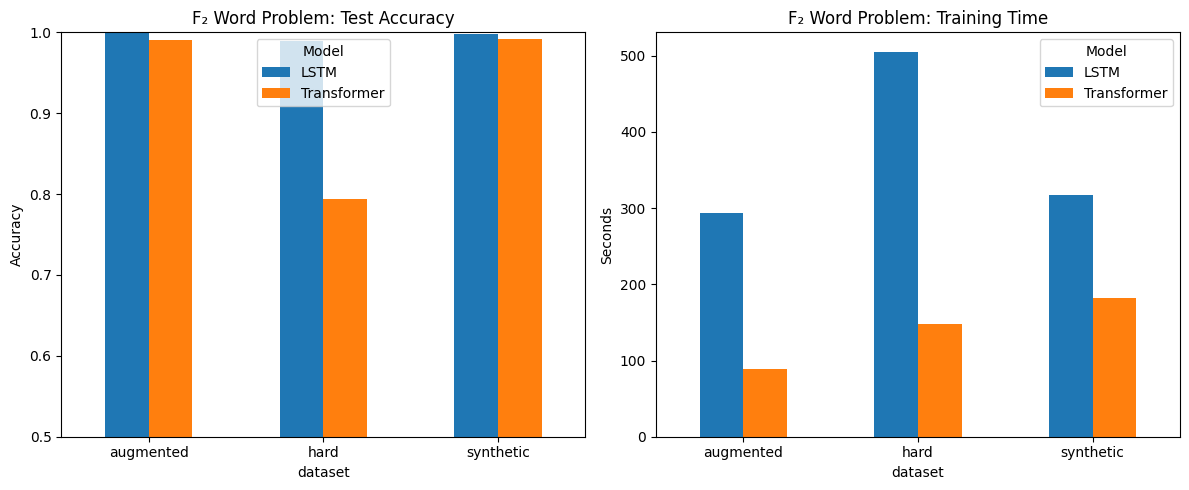


Visualization saved to /content/drive/MyDrive/word_problem_results/F2/f2_results.png


In [13]:
# Display summary
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(results_df.to_string(index=False))

# %% CELL 15: Summary Statistics
summary = results_df.groupby(['model', 'dataset']).agg({
    'test_acc': ['mean', 'std'],
    'train_time': 'mean'
}).round(4)

print("\n" + "="*60)
print("AGGREGATED RESULTS (mean ± std)")
print("="*60)
print(summary)

# Save summary
summary.to_csv(f'{OUTPUT_DIR}/f2_summary.csv')

# %% CELL 16: Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Test accuracy by model and dataset
pivot = results_df.pivot_table(values='test_acc', index='dataset', columns='model', aggfunc='mean')
pivot.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('F₂ Word Problem: Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title='Model')

# Plot 2: Training time
pivot_time = results_df.pivot_table(values='train_time', index='dataset', columns='model', aggfunc='mean')
pivot_time.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('F₂ Word Problem: Training Time')
axes[1].set_ylabel('Seconds')
axes[1].legend(title='Model')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/f2_results.png', dpi=150)
plt.show()

print(f"\nVisualization saved to {OUTPUT_DIR}/f2_results.png")